# 妨害名譽罪名分類專案 — 進度報告

最後更新：2026-10-03

這份 notebook 用圖表 + 白話說明整個專案的進度。**第一次看的同仁建議先跳到最後的
「第 9 節：給同仁的重點摘要」**，再回頭看細節。

1. **抓資料**（第 1 節）：從司法院判決書網站爬「妨害名譽」相關刑事判決
2. **訓練模型**（第 2~4 節）：整理成「一句網路留言 → 罪名」的分類任務，
   比較 5 個中文 HuggingFace 模型
3. **合併標籤實驗**（第 5 節）：把三個誹謗類罪名併成一類，驗證「標籤太細」的假設
4. **運行成本比較**（第 6 節）：訓練時間與 GPU 記憶體
5. **提升準確度實驗**（第 7~8 節）：固定模型、改動資料與訓練技術，9 個消融實驗

> 目標：餵給模型一句網路留言（例如「你這個智障」），讓它猜出這句話構成
> `公然侮辱`、`加重誹謗`、`散布文字誹謗`、`誹謗`，還是最後被判`無罪`。

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

# 讓圖表能正常顯示繁體中文（Windows 內建的微軟正黑體）
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

ML_ROOT = Path.cwd() if Path.cwd().name == "ml" else Path.cwd() / "ml"
ROOT = ML_ROOT.parent


C:\Users\User\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 第一步：抓資料

爬蟲（`dataset/crawler_defamation.py`）去司法院判決書查詢系統，用「案由＝妨害名譽」查
刑事案件。網站一次查詢最多只給看 500 筆結果，所以爬蟲把判決日期切成一段一段去查，
確保每一段都在 500 筆以內，再把每一段的結果分別抓完。

抓到判決全文後，用兩種方法從裡面挖出「被告講了什麼話」跟「判了什麼罪」：

- **精準版**：如果判決書裡剛好附了檢察官起訴書的表格（日期/平台/帳號/內容/罪名都列好），
  就直接照表格一列一列抓，品質最好、也保有社交平台、帳號等完整資訊。
- **備用版**：大部分判決書沒有這種表格，只能改用比較粗的規則——去判決書裡找
  用「」括起來的句子當作是被告講的話，再從判決結果那句話裡用關鍵字比對抓出罪名
  （例如「...犯散布文字誹謗罪...」→ 抓出「散布文字誹謗」）。這個方法簡單但雜訊也比較多。

下圖是資料量在整個流程中的變化：

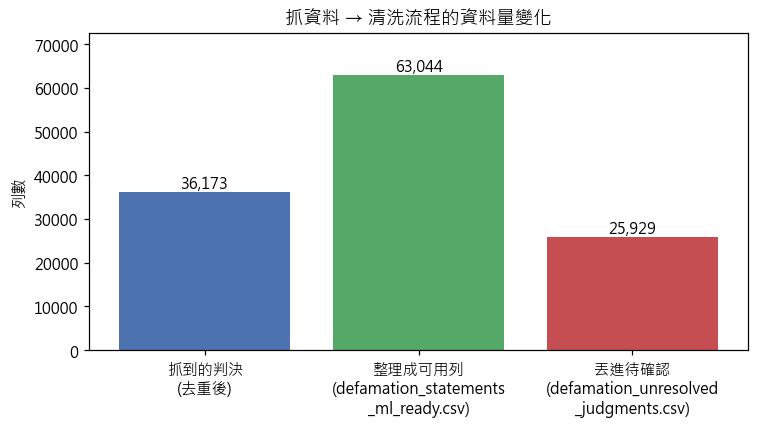

In [2]:
stages = {
    "抓到的判決\n(去重後)": 36_173,
    "整理成可用列\n(defamation_statements\n_ml_ready.csv)": 63_044,
    "丟進待確認\n(defamation_unresolved\n_judgments.csv)": 25_929,
}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(stages.keys(), stages.values(), color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("列數")
ax.set_title("抓資料 → 清洗流程的資料量變化")
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{int(b.get_height()):,}",
            ha="center", va="bottom", fontsize=10)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()


**怎麼讀這張圖**：一開始抓到 36,173 份不重複的判決書。因為每份判決書可能提到
好幾句被告講的話，經過兩種抓法整理後可用的資料列展開成 63,044 列（一列＝一句話 +
它的罪名）。另外有 25,929 列因為抓不到明確的言論內容或罪名，先放進「待確認」，
不會拿去訓練模型（寧可少用一點資料，也不要用猜的去填空）。

## 第二步：訓練模型分類

### 2.1 先把標籤縮減到 5 種

原始資料裡「罪名」欄位寫法五花八門，一共有 102 種不同的字串，其中很多根本不是罪名，
是判決的「程序性結果」，例如：

- `上訴駁回。`
- `原告之訴駁回。`
- `再審之聲請駁回。`

這次任務只挑 5 種目標標籤：`公然侮辱`、`加重誹謗`、`散布文字誹謗`、`誹謗`、`無罪`。

### 2.2 三個清洗步驟（缺一不可）

1. **去重複** — 爬蟲是可以中斷續抓的設計，重跑常常會抓到一樣的句子，34% 的列是完全
   重複，直接刪除。
2. **丟棄「一句話對到好幾種罪名」的矛盾資料** — 備用版抓法會把判決書裡任何「」引號
   內容都當作是被告講的話，結果連判決書的法律固定用語（例如「意圖散布於眾」）都被
   當成言論抓進來，同一句法律套語會同時掛在好幾種不同罪名下。這種矛盾資料代表它根本
   不是真的網路留言，整批刪除，不亂猜一個標籤給它。
3. **刪掉太短的碎句** — 少於 6 個字的殘留片段（像「同仁」、「、」）沒有語意可判斷。

### 2.3 切資料時最容易犯的錯：不能用「隨機」切

清洗完剩下的句子，只來自 6,990 份判決書，而同一份判決書拆出來的句子往往內容很像、
標籤也一樣。如果隨機把資料切成「訓練用」跟「考試用」，同一份判決的句子可能一邊一句，
AI 會靠「背這份判決長怎樣」拿高分，而不是真的學會判斷語意——分數會虛高，沒有參考價值。

解法：改用「整份判決」當作切分單位，確保同一份判決的句子只會出現在訓練或考試其中一邊，
不會同時出現在兩邊。

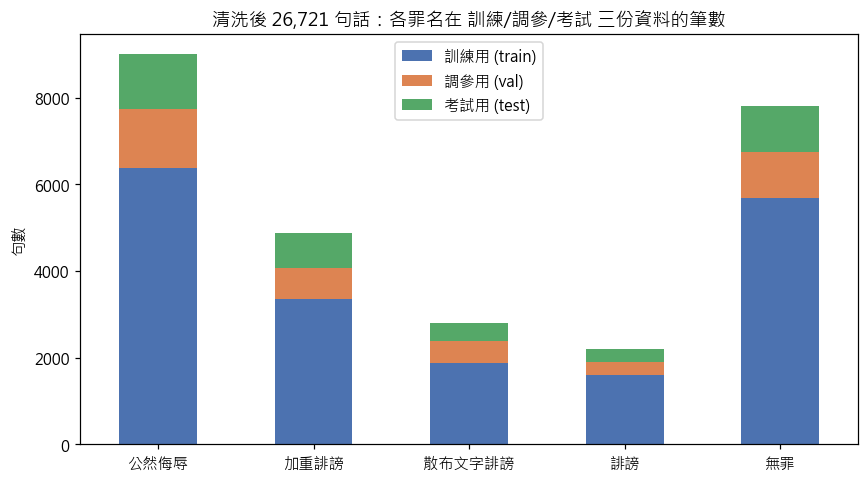

總計 26,721 句，來自 6,990 份判決
        train   val  test    合計
涉犯罪名                           
公然侮辱     6385  1361  1268  9014
加重誹謗     3352   722   812  4886
散布文字誹謗   1870   517   423  2810
誹謗       1594   316   292  2202
無罪       5674  1078  1057  7809


In [3]:
label_map = json.loads((ML_ROOT / "data" / "label_map.json").read_text(encoding="utf-8"))
labels = label_map["labels"]

splits = {
    name: pd.read_csv(ML_ROOT / "data" / f"{name}.csv", encoding="utf-8-sig")
    for name in ("train", "val", "test")
}

counts = pd.DataFrame({
    name: df["涉犯罪名"].value_counts().reindex(labels).fillna(0).astype(int)
    for name, df in splits.items()
})
counts = counts.reindex(labels)

fig, ax = plt.subplots(figsize=(8, 4.5))
counts.plot(kind="bar", stacked=True, ax=ax,
            color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("清洗後 26,721 句話：各罪名在 訓練/調參/考試 三份資料的筆數")
ax.set_ylabel("句數")
ax.set_xlabel("")
ax.legend(["訓練用 (train)", "調參用 (val)", "考試用 (test)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"總計 {counts.values.sum():,} 句，來自 6,990 份判決")
print(counts.assign(合計=counts.sum(axis=1)))


**怎麼讀這張圖**：`公然侮辱` 跟 `無罪` 這兩類資料量最多，`誹謗` 最少——這是真實
世界的類別不平衡，不是切分造成的。後面評分時會用「macro-F1」而不是單純的猜中率，
避免分數被資料量最多的兩類主導。

### 2.4 選哪些模型來比較

去 HuggingFace（AI 模型下載平台）用**下載量**排序，分兩組各挑幾個：

- **通用中文模型 Top 3**：不限定領域，下載量最高的中文文本模型
- **法律領域模型 Top 2**：專門拿法律/判決書文字訓練過的中文模型，下載量最高的兩個

後兩個的目的是驗證一個假設：「AI 有沒有讀過法律文件，猜罪名會不會比較準？」

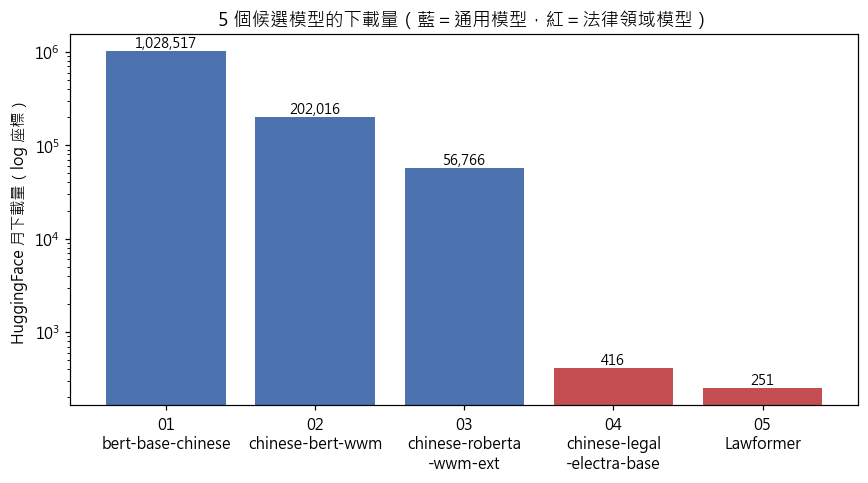

In [4]:
hf_downloads = {
    "01\nbert-base-chinese": 1_028_517,
    "02\nchinese-bert-wwm": 202_016,
    "03\nchinese-roberta\n-wwm-ext": 56_766,
    "04\nchinese-legal\n-electra-base": 416,
    "05\nLawformer": 251,
}
group_color = ["#4C72B0"] * 3 + ["#C44E52"] * 2

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(hf_downloads.keys(), hf_downloads.values(), color=group_color)
ax.set_yscale("log")
ax.set_ylabel("HuggingFace 月下載量（log 座標）")
ax.set_title("5 個候選模型的下載量（藍＝通用模型，紅＝法律領域模型）")
for i, v in enumerate(hf_downloads.values()):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


**怎麼讀這張圖**：注意 y 軸是 log（對數）座標——法律領域模型的下載量比通用模型
低了整整三個數量級（幾百 vs 幾十萬到上百萬）。這不代表法律模型不好，而是中文法律
NLP 這個小眾領域的預訓練生態本來就小，這兩個已經是 HuggingFace 上的天花板。

## 3. 訓練結果

評分用的是 **macro-F1**：5 個罪名各自算一個猜中率分數，再取平均，不會因為
「公然侮辱」跟「無罪」筆數多就佔便宜。滿分 1，越高越準。

> 目前 5 個模型中，Lawformer（05）序列較長、batch 較小，訓練時間也比其他 4 個久，
> 若這裡看到它缺席，代表當時還在跑；重新執行這個 notebook 就會補上。

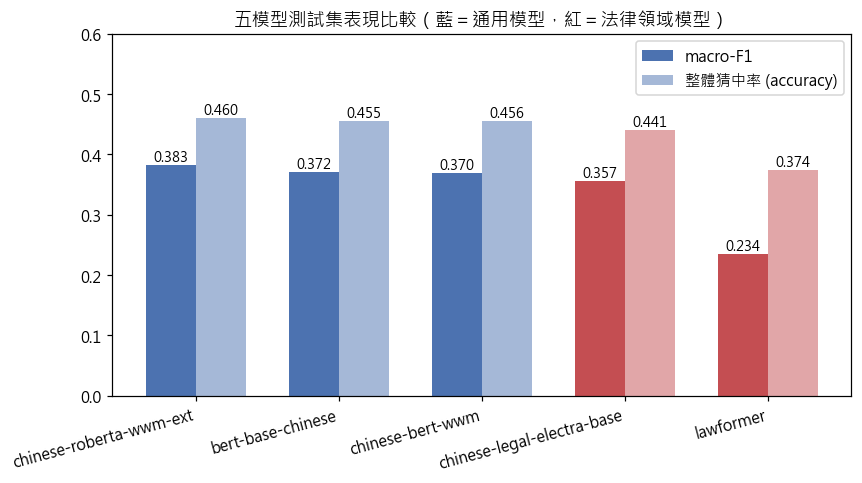

In [5]:
GROUP = {
    "01_bert-base-chinese": "通用",
    "02_chinese-bert-wwm": "通用",
    "03_chinese-roberta-wwm-ext": "通用",
    "04_chinese-legal-electra-base": "法律",
    "05_lawformer": "法律",
}

results = {}
for folder in GROUP:
    p = ML_ROOT / folder / "results.json"
    if p.exists():
        results[folder] = json.loads(p.read_text(encoding="utf-8"))

missing = [f for f in GROUP if f not in results]
if missing:
    print("尚未完成、圖表中會缺席：", missing)

order = sorted(results, key=lambda f: results[f]["test_macro_f1"], reverse=True)
macro_f1 = [results[f]["test_macro_f1"] for f in order]
acc = [results[f]["test_accuracy"] for f in order]
colors = ["#4C72B0" if GROUP[f] == "通用" else "#C44E52" for f in order]

x = np.arange(len(order))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width / 2, macro_f1, width, label="macro-F1", color=colors)
ax.bar(x + width / 2, acc, width, label="整體猜中率 (accuracy)", color=colors, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels([f.split("_", 1)[1] for f in order], rotation=15, ha="right")
ax.set_ylim(0, 0.6)
ax.set_title("五模型測試集表現比較（藍＝通用模型，紅＝法律領域模型）")
ax.legend()
for i, (m, a) in enumerate(zip(macro_f1, acc)):
    ax.text(i - width / 2, m, f"{m:.3f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + width / 2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


**怎麼讀這張圖**：四個 base 尺寸模型（bert-base-chinese / chinese-bert-wwm /
chinese-roberta-wwm-ext / chinese-legal-electra-base）分數確實很接近，落在
0.357～0.383 之間。但 **Lawformer 是明顯的離群值**，只有 0.234，比其他四個
低了 0.12～0.15（相對落後約 4 成），不能算在「分數都接近」裡——下一節的運行時間
比較會看到，Lawformer 不只分數最低，耗時還是其他模型的 15 倍以上，是全面落後。

比較意外的是「有讀過法律文件的 AI」(legal-electra) 並沒有比普通 AI 準，甚至還略輸
`chinese-roberta-wwm-ext`——可能原因是法律模型是拿「判決書全文」的書面文體訓練的，
但這次要猜的是「網路留言」的口語、髒話、諧音字，兩種文體落差太大，法律知識沒有
派上用場。

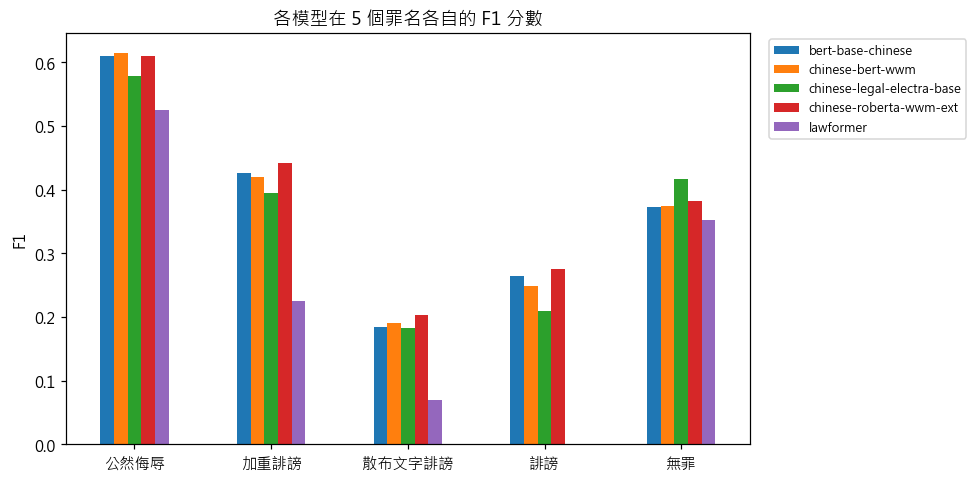

In [6]:
rows = []
for f in order:
    r = results[f]
    for label, f1 in r["per_class_f1"].items():
        rows.append({"模型": f.split("_", 1)[1], "罪名": label, "F1": f1})
pcf = pd.DataFrame(rows).pivot(index="罪名", columns="模型", values="F1").reindex(labels)

fig, ax = plt.subplots(figsize=(9, 4.5))
pcf.plot(kind="bar", ax=ax)
ax.set_title("各模型在 5 個罪名各自的 F1 分數")
ax.set_ylabel("F1")
ax.set_xlabel("")
plt.xticks(rotation=0)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


**怎麼讀這張圖**：每個模型都是同樣的規律——`公然侮辱` 最準（F1 約 0.5～0.6），
`誹謗` 跟 `散布文字誹謗` 最不準（F1 常常只有 0.2 上下）。這不是模型不夠好，而是
`加重誹謗` / `散布文字誹謗` / `誹謗` 這三個類別在刑法上其實是**同一條法條（刑法 310 條）
的不同講法**，連寫判決書的法官用詞都不完全一致，AI 分不清楚三者的界線是合理的。

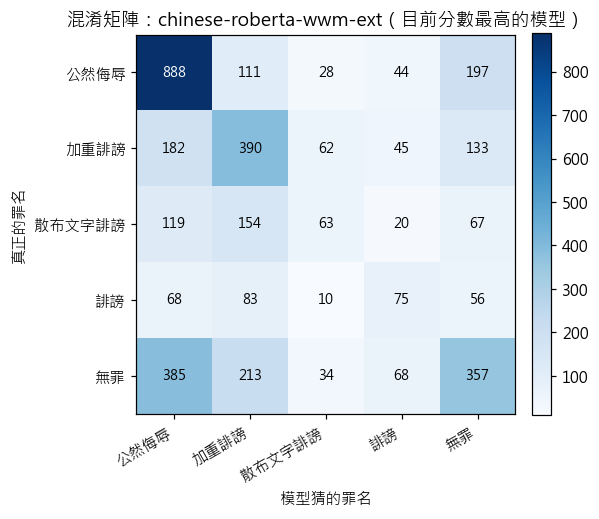

In [7]:
best = order[0]
cm = np.array(results[best]["confusion_matrix"])

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("模型猜的罪名")
ax.set_ylabel("真正的罪名")
ax.set_title(f"混淆矩陣：{best.split('_', 1)[1]}（目前分數最高的模型）")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=9)
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


**怎麼讀這張圖（混淆矩陣）**：對角線（左上到右下）是「猜對」的數量，顏色越深、
數字越大代表猜對越多。看橫排就能看出每個真實罪名最常被誤判成什麼——如果你看到
`加重誹謗`那一列在`散布文字誹謗`欄位、`誹謗`那一列在`加重誹謗`欄位的數字也不小，
就印證了前面說的：這三類彼此界線模糊，模型常常在這三者之間猜錯，但很少會把
`公然侮辱`跟這三類搞混（因為公然侮辱的語意——罵髒話、貶低人格——跟誹謗類需要的
「指摘具體事實」語意差很多）。

## 4. 結論與已知限制

- 四個 base 尺寸模型分數相近（0.357～0.383），`chinese-roberta-wwm-ext` 領先；
  但法律領域模型並沒有展現預期中的優勢——可能是訓練語料的文體（判決書全文 vs
  網路口語留言）落差太大。Lawformer 則是明顯的離群值（0.234），不在「分數相近」
  之列，見上一節的說明。
- 真正拉低整體分數的是 `加重誹謗` / `散布文字誹謗` / `誹謗` 三類彼此糾纏，這是
  **標籤定義本身的問題**，不是模型能力問題。下一步可以試著把這三類合併成一類，
  驗證分數會不會明顯回升。
- `無罪` 這個標籤代表的是「判決結果」而非言論本身的性質，同一句話可能因為證據不足
  被判無罪，言論內容本身不一定帶有可學的訊號，這類的分數預期本來就會偏低。
- 目前 63,044 筆可用資料裡，只有 176 筆來自最高品質的「起訴書表格」抓法，其餘都是
  備用規則抓出來的，缺少日期/平台/帳號等額外資訊可以當作模型特徵使用。

原始檔案位置：
- 抓資料：`dataset/crawler_defamation.py`、`dataset/clean_dataset.py`
- 訓練模型：`ml/prepare_data.py`、`ml/common.py`、`ml/0X_*/train.py`
- 完整表格版比較：`ml/RESULTS.md`

## 5. 追加實驗：把三個誹謗類罪名合併成一類

上面第 4 節的結論提到：拉低分數的主因是 `加重誹謗` / `散布文字誹謗` / `誹謗` 三類
彼此糾纏，而這三類在刑法上其實同屬**第 310 條**的不同講法。這一節驗證：如果把這三類
合併成一個「誹謗類」，分數會不會回升？

**這是一份完全獨立、不覆寫上面任何結果的追加實驗**：
- 資料準備：新檔案 `ml/prepare_data_merged.py` → 新目錄 `ml/data_merged/`
  （原本的 `ml/prepare_data.py`、`ml/data/` 完全沒動）
- 模型訓練：新資料夾 `ml/06`～`ml/10`，模型與超參數逐一對應原本的 `01`～`05`，
  只換資料來源，方便兩組結果直接對照
- 標籤合併規則：`加重誹謗`／`散布文字誹謗`／`誹謗` → 統一改叫 `誹謗類`；
  `公然侮辱`、`無罪` 不變

合併後還多回收了一批資料——原本 5 類任務裡「一句話被貼過不只一種細分標籤」
（例如同一句話曾同時被標成`加重誹謗`和`誹謗`）的矛盾資料會被整批丟棄；合併之後
這兩個標籤都變成`誹謗類`，不再矛盾，可以留下來用。因此可用列數從 26,721 筆
回升到 27,088 筆。

> 訓練佇列會接在第 4 節的 5 個模型之後自動執行（同一張 GPU 沒辦法同時跑兩個任務）。
> 如果下面圖表顯示「尚未有結果」，代表訓練還在背景進行，重新執行這個 notebook
> 就會補上。

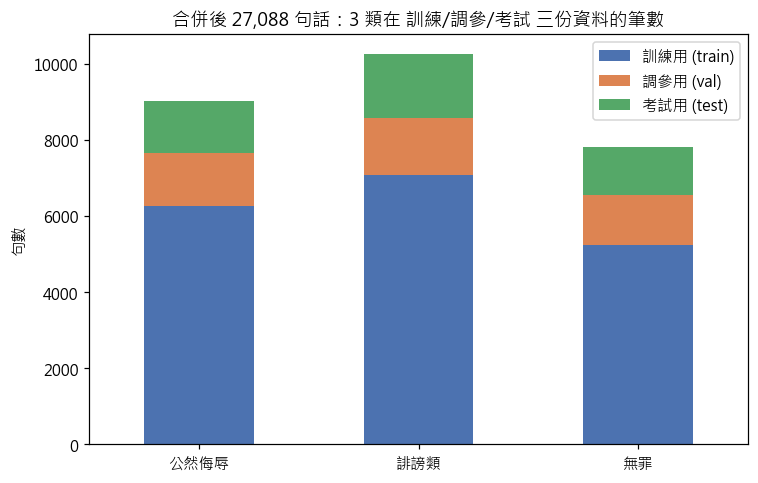

總計 27,088 句，來自 7,048 份判決（3 個 split 各自的判決數相加）
      train   val  test     合計
涉犯罪名                          
公然侮辱   6259  1388  1367   9014
誹謗類    7089  1478  1698  10265
無罪     5242  1318  1249   7809


In [8]:
merged_label_map = json.loads((ML_ROOT / "data_merged" / "label_map.json").read_text(encoding="utf-8"))
merged_labels = merged_label_map["labels"]

merged_splits = {
    name: pd.read_csv(ML_ROOT / "data_merged" / f"{name}.csv", encoding="utf-8-sig")
    for name in ("train", "val", "test")
}

merged_counts = pd.DataFrame({
    name: df["涉犯罪名"].value_counts().reindex(merged_labels).fillna(0).astype(int)
    for name, df in merged_splits.items()
}).reindex(merged_labels)

fig, ax = plt.subplots(figsize=(7, 4.5))
merged_counts.plot(kind="bar", stacked=True, ax=ax,
                    color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title(f"合併後 {merged_counts.values.sum():,} 句話：3 類在 訓練/調參/考試 三份資料的筆數")
ax.set_ylabel("句數")
ax.set_xlabel("")
ax.legend(["訓練用 (train)", "調參用 (val)", "考試用 (test)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"總計 {merged_counts.values.sum():,} 句，來自 {merged_splits['train']['原文網址'].nunique() + merged_splits['val']['原文網址'].nunique() + merged_splits['test']['原文網址'].nunique():,} 份判決（3 個 split 各自的判決數相加）")
print(merged_counts.assign(合計=merged_counts.sum(axis=1)))


**怎麼讀這張圖**：三類的資料量比原本 5 類均衡不少——`誹謗類`（合併後）筆數變成最多，
跟`公然侮辱`、`無罪`落在同一個量級，不再是資料量最少的類別。

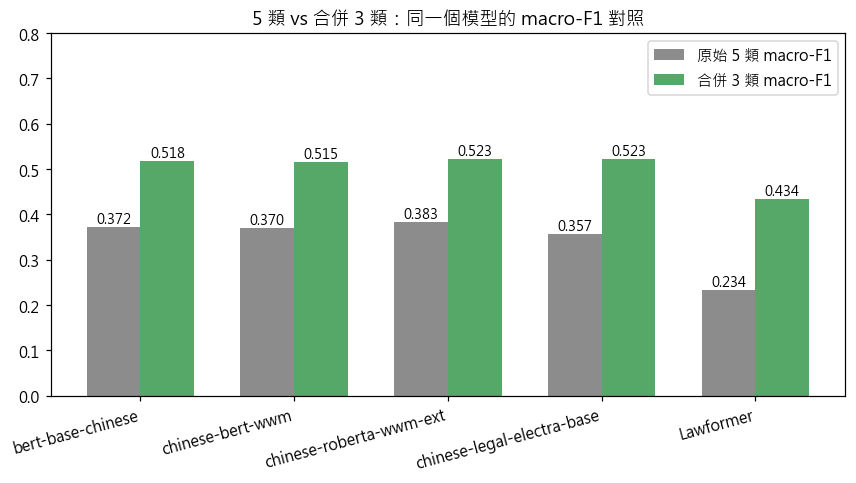

In [9]:
MERGED_PAIRS = [
    ("01_bert-base-chinese", "06_bert-base-chinese_merged", "bert-base-chinese"),
    ("02_chinese-bert-wwm", "07_chinese-bert-wwm_merged", "chinese-bert-wwm"),
    ("03_chinese-roberta-wwm-ext", "08_chinese-roberta-wwm-ext_merged", "chinese-roberta-wwm-ext"),
    ("04_chinese-legal-electra-base", "09_chinese-legal-electra-base_merged", "chinese-legal-electra-base"),
    ("05_lawformer", "10_lawformer_merged", "Lawformer"),
]


def _load(folder):
    p = ML_ROOT / folder / "results.json"
    return json.loads(p.read_text(encoding="utf-8")) if p.exists() else None


pair_results = [(name, _load(o), _load(m)) for o, m, name in MERGED_PAIRS]
done_pairs = [(name, o, m) for name, o, m in pair_results if m is not None]
pending = [name for name, o, m in pair_results if m is None]

if pending:
    print("合併標籤實驗尚未完成、圖表中會缺席：", pending)

if not done_pairs:
    print("目前還沒有任何合併標籤實驗的結果，訓練仍在背景進行中。")
else:
    names = [n for n, o, m in done_pairs]
    orig_f1 = [o["test_macro_f1"] if o else np.nan for n, o, m in done_pairs]
    merged_f1 = [m["test_macro_f1"] for n, o, m in done_pairs]

    x = np.arange(len(names))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(x - width / 2, orig_f1, width, label="原始 5 類 macro-F1", color="#8C8C8C")
    ax.bar(x + width / 2, merged_f1, width, label="合併 3 類 macro-F1", color="#55A868")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha="right")
    ax.set_ylim(0, 0.8)
    ax.set_title("5 類 vs 合併 3 類：同一個模型的 macro-F1 對照")
    ax.legend()
    for i, (o, m) in enumerate(zip(orig_f1, merged_f1)):
        if not np.isnan(o):
            ax.text(i - width / 2, o, f"{o:.3f}", ha="center", va="bottom", fontsize=9)
        ax.text(i + width / 2, m, f"{m:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


**怎麼判讀這張圖**：
- 如果綠色（合併 3 類）明顯高於灰色（原始 5 類），代表拉低分數的真的是「標籤切得太細」，
  下游應用把細分罪名拿掉、只判斷「有沒有構成誹謗類」會更實際可用。
- 如果合併後分數沒什麼變化，代表混淆不只是標籤粒度的問題，可能是「誹謗」需要的
  「指摘具體事實」語意本身，從單句留言就很難判斷。

本節會在背景訓練完成後自動補上完整的每類別 F1 與結論；目前先看上面的圖表有沒有資料。

## 6. 運行時間與資源使用比較

除了準確度，實際挑模型時也要考慮「訓練要等多久、吃多少 GPU 記憶體」。
這台機器是 RTX 4060（8GB VRAM）。`01`～`10` 全部模型都是用同一版加了計時與 GPU
峰值記憶體量測的 `common.py` 訓練出來的，以下都是實測數據，不是回推值。

                            耗時(分鐘)  峰值GPU記憶體(GB)  參數量(M)
模型                                                      
bert-base-chinese             6.65          4.50  102.27
chinese-bert-wwm              6.55          4.50  102.27
chinese-roberta-wwm-ext       6.52          4.50  102.27
chinese-legal-electra-base    6.56          4.50  102.27
Lawformer                   103.62          2.28  126.29


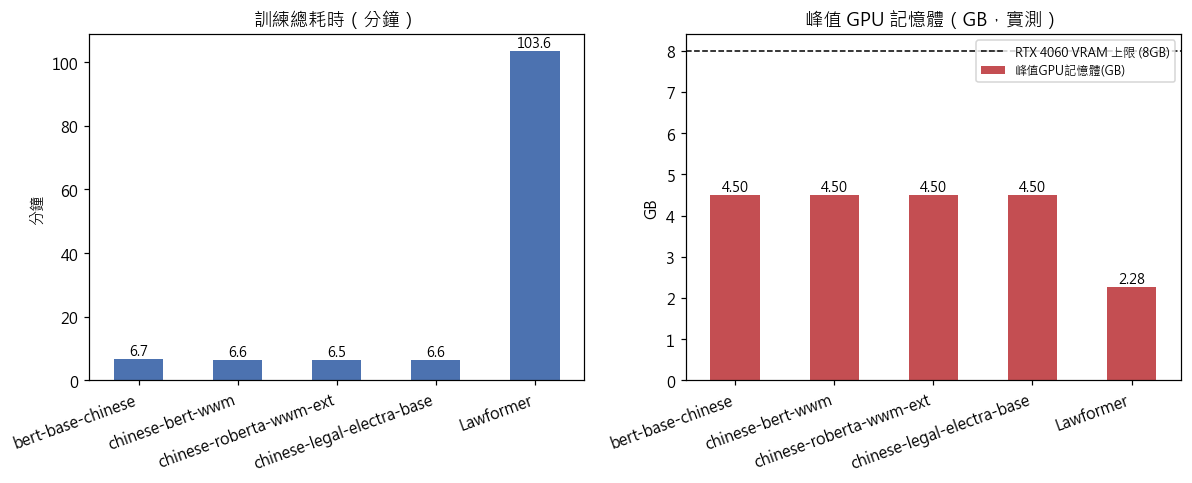

In [10]:
TIMING_PAIRS = [
    ("01_bert-base-chinese", "06_bert-base-chinese_merged", "bert-base-chinese"),
    ("02_chinese-bert-wwm", "07_chinese-bert-wwm_merged", "chinese-bert-wwm"),
    ("03_chinese-roberta-wwm-ext", "08_chinese-roberta-wwm-ext_merged", "chinese-roberta-wwm-ext"),
    ("04_chinese-legal-electra-base", "09_chinese-legal-electra-base_merged", "chinese-legal-electra-base"),
    ("05_lawformer", "10_lawformer_merged", "Lawformer"),
]

timing_rows = []
for orig_folder, merged_folder, name in TIMING_PAIRS:
    orig = _load(orig_folder)
    merged = _load(merged_folder)
    # 01~10 現在都用同一版有計時的 common.py 訓練，兩邊各自都有實測值；
    # 以 5 類任務(orig)的數字為主，缺的話才退回合併任務(merged)的數字。
    wall = (orig or {}).get("total_wall_clock_seconds") or (merged or {}).get("total_wall_clock_seconds")
    mem = (orig or {}).get("peak_gpu_memory_allocated_mb") or (merged or {}).get("peak_gpu_memory_allocated_mb")
    params = (orig or merged or {}).get("num_parameters")
    timing_rows.append({"模型": name, "耗時(分鐘)": wall / 60 if wall else np.nan,
                         "峰值GPU記憶體(GB)": mem / 1024 if mem else np.nan,
                         "參數量(M)": params / 1e6 if params else np.nan})

timing_df = pd.DataFrame(timing_rows).set_index("模型")
print(timing_df.round(2))

if timing_df["耗時(分鐘)"].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    timing_df["耗時(分鐘)"].plot(kind="bar", ax=axes[0], color="#4C72B0")
    axes[0].set_title("訓練總耗時（分鐘）")
    axes[0].set_ylabel("分鐘")
    axes[0].set_xlabel("")
    for i, v in enumerate(timing_df["耗時(分鐘)"]):
        if not np.isnan(v):
            axes[0].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)

    if timing_df["峰值GPU記憶體(GB)"].notna().any():
        timing_df["峰值GPU記憶體(GB)"].plot(kind="bar", ax=axes[1], color="#C44E52")
        axes[1].set_title("峰值 GPU 記憶體（GB，實測）")
        axes[1].set_ylabel("GB")
        axes[1].set_xlabel("")
        axes[1].axhline(8, color="black", linestyle="--", linewidth=1, label="RTX 4060 VRAM 上限 (8GB)")
        axes[1].legend(fontsize=8)
        for i, v in enumerate(timing_df["峰值GPU記憶體(GB)"]):
            if not np.isnan(v):
                axes[1].text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    else:
        axes[1].text(0.5, 0.5, "尚無實測記憶體數據",
                     ha="center", va="center", transform=axes[1].transAxes)
        axes[1].axis("off")

    for ax in axes:
        plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("尚無耗時資料可畫圖。")


**怎麼讀這兩張圖**：
- 左圖是訓練一次要等多久。四個 base 尺寸模型（bert-base-chinese / chinese-bert-wwm /
  chinese-roberta-wwm-ext / chinese-legal-electra-base）耗時應該很接近——它們參數量
  相同（102M）、輸入長度和 batch size 也相同，差異主要來自模型架構細節。
  Lawformer 因為用了 2 倍的輸入長度（512 vs 256）、batch size 只有 1/4（8 vs 32），
  預期會明顯拉長。
- 右圖是峰值 GPU 記憶體，虛線是這台機器 RTX 4060 的 8GB 上限——如果某個模型的柱子
  接近或超過這條線，代表這組 batch size／長度設定已經逼近這張顯卡的極限，
  之後想加大 batch size 得先降別的參數。Lawformer 已經另外開了 gradient
  checkpointing（用計算時間換記憶體）才有辦法在 8GB 卡上跑 512 長度。
- 實務上選模型不能只看 macro-F1：如果 `chinese-roberta-wwm-ext` 分數最高、
  又跟其他 base 模型耗時差不多，那是明確的首選；但如果 Lawformer 的分數優勢
  必須靠數倍的訓練時間換來，這筆帳值不值得就要看實際部署的時間/資源預算。

## 7. 第三種實驗：想辦法提高準確度

前面兩種實驗（第 3 節的 5 類、第 5 節的合併 3 類）都只在**換模型**，資料本身從頭到尾
沒再處理過。第三種實驗反過來：**固定住最佳模型，改動資料與訓練技術**，看準確度還能推多高。

> **原始資料全程沒有被更動**：`ml/data/`、`ml/data_merged/` 唯讀，另外完整備份在
> `ml/_backup_original/`（已用 md5 驗證一致）。所有新資料都寫在 `ml/exp3_accuracy/`。

### 怎麼確保比較是公平的

一共跑了 9 個消融實驗，每次只改一個變數，而且**全部在同一份未過濾的測試集（4,314 筆）
上評分**。這點很關鍵：如果連測試集都一起清洗，分數一定會變好看，但那是因為
「把難的題目刪掉了」，不是模型真的變強。

判定門檻用先前重跑實驗量到的正常波動 **±0.013**（見 `RESULTS_rerun_check.md`），
提升要超過這個幅度才算真的有效，否則可能只是 fp16 訓練的隨機誤差。

第一個實驗 `E0` 跑的是完全未處理的資料，結果是 **0.5232 —— 完全重現基準線**，
證明這套新的實驗管線本身可信，後面的比較才有意義。

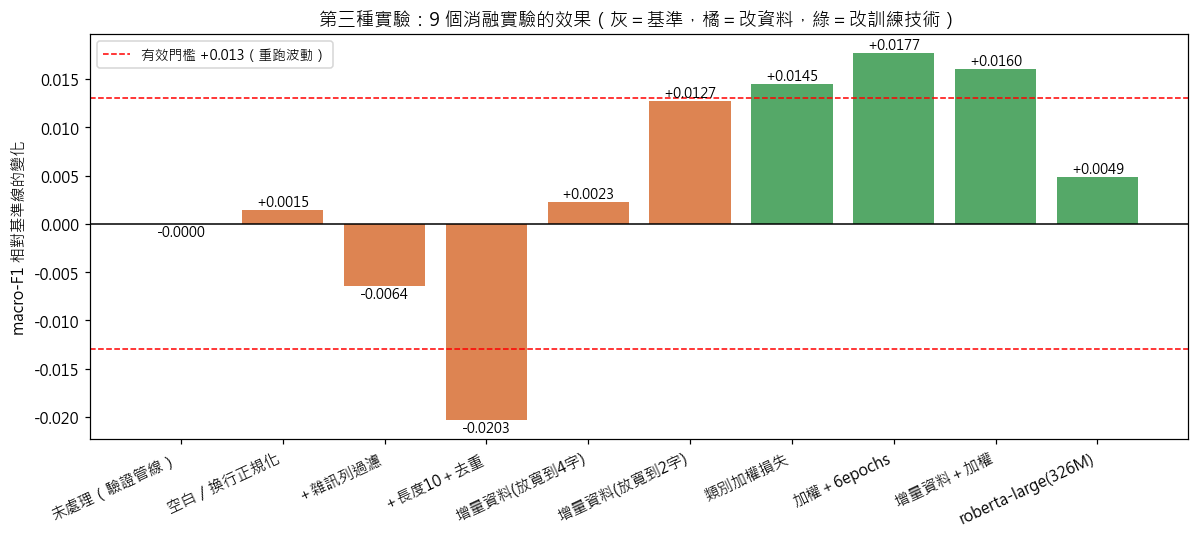

                 實驗 類型  train筆數  macro_f1        提升
          未處理（驗證管線） 基準    18590  0.523183 -0.000017
           空白／換行正規化 資料    18106  0.524663  0.001463
             ＋雜訊列過濾 資料    15173  0.516803 -0.006397
           ＋長度10＋去重 資料    10999  0.502855 -0.020345
        增量資料(放寬到4字) 資料    20945  0.525469  0.002269
        增量資料(放寬到2字) 資料    23422  0.535926  0.012726
             類別加權損失 技術    18106  0.537717  0.014517
         加權＋6epochs 技術    18106  0.540938  0.017738
            增量資料＋加權 技術    20945  0.539212  0.016012
roberta-large(326M) 技術    18106  0.528087  0.004887


In [11]:
EXP3 = ML_ROOT / "exp3_accuracy" / "runs"
BASELINE_3CLS = 0.5232     # 08_chinese-roberta-wwm-ext_merged
NOISE_FLOOR = 0.013        # 重跑同設定的正常波動

EXP3_ORDER = [
    ("E0_baseline",      "未處理（驗證管線）",     "基準"),
    ("E1_normalize",     "空白／換行正規化",       "資料"),
    ("E2_denoise",       "＋雜訊列過濾",           "資料"),
    ("E3_denoise10",     "＋長度10＋去重",         "資料"),
    ("E7_more_len4",     "增量資料(放寬到4字)",    "資料"),
    ("E8_more_len2",     "增量資料(放寬到2字)",    "資料"),
    ("E4_weighted",      "類別加權損失",           "技術"),
    ("E5_weighted_6ep",  "加權＋6epochs",          "技術"),
    ("E9_more_weighted", "增量資料＋加權",         "技術"),
    ("E6_large",         "roberta-large(326M)",    "技術"),
]

exp3 = []
for key, desc, kind in EXP3_ORDER:
    p = EXP3 / key / "results.json"
    if not p.exists():
        continue
    r = json.loads(p.read_text(encoding="utf-8"))
    exp3.append({"實驗": desc, "類型": kind,
                 "macro_f1": r["main_test"]["macro_f1"],
                 "train筆數": r["n_train"],
                 "耗時": r["total_wall_clock_seconds"] / 60})

e3 = pd.DataFrame(exp3)
e3["提升"] = e3["macro_f1"] - BASELINE_3CLS

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#8C8C8C" if k == "基準" else ("#DD8452" if k == "資料" else "#55A868")
          for k in e3["類型"]]
bars = ax.bar(e3["實驗"], e3["提升"], color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(NOISE_FLOOR, color="red", linestyle="--", linewidth=1,
           label=f"有效門檻 +{NOISE_FLOOR}（重跑波動）")
ax.axhline(-NOISE_FLOOR, color="red", linestyle="--", linewidth=1)
ax.set_ylabel("macro-F1 相對基準線的變化")
ax.set_title("第三種實驗：9 個消融實驗的效果（灰＝基準，橘＝改資料，綠＝改訓練技術）")
ax.legend(fontsize=9)
for b, v in zip(bars, e3["提升"]):
    ax.text(b.get_x() + b.get_width() / 2, v,
            f"{v:+.4f}", ha="center",
            va="bottom" if v >= 0 else "top", fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.show()

print(e3[["實驗", "類型", "train筆數", "macro_f1", "提升"]].to_string(index=False))


**怎麼讀這張圖**：紅色虛線是「有效門檻」，柱子要超過它才算真的有效，不然就只是隨機誤差。

**橘色（改資料）全部沒過關，而且過濾越兇越差。** 這推翻了一開始的假設。資料確實很髒
（51% 帶判決書排版換行、約 9% 是法庭問答逐字稿或法條引用），但清洗它沒有幫助。

最有說服力的反證是：**把測試集也清洗過之後，分數並沒有上升**（0.5156 vs 0.5232）。
如果那些被判定為「雜訊」的列真的是無法分類的垃圾，把它們從測試集刪掉應該讓分數**上升**
才對——結果反而略降，代表那些列**並不比其他資料難分類**，模型確實有從中學到東西。

**綠色（改訓練技術）裡，「類別加權」是唯一真正有效的。** 而且成本是零——
訓練時間跟基準線一樣只要 7 分鐘。相對地，`roberta-large` 模型大 3 倍、
訓練久 15 倍（105 分鐘）、GPU 吃到 8.3GB 快爆卡，提升卻沒過門檻。

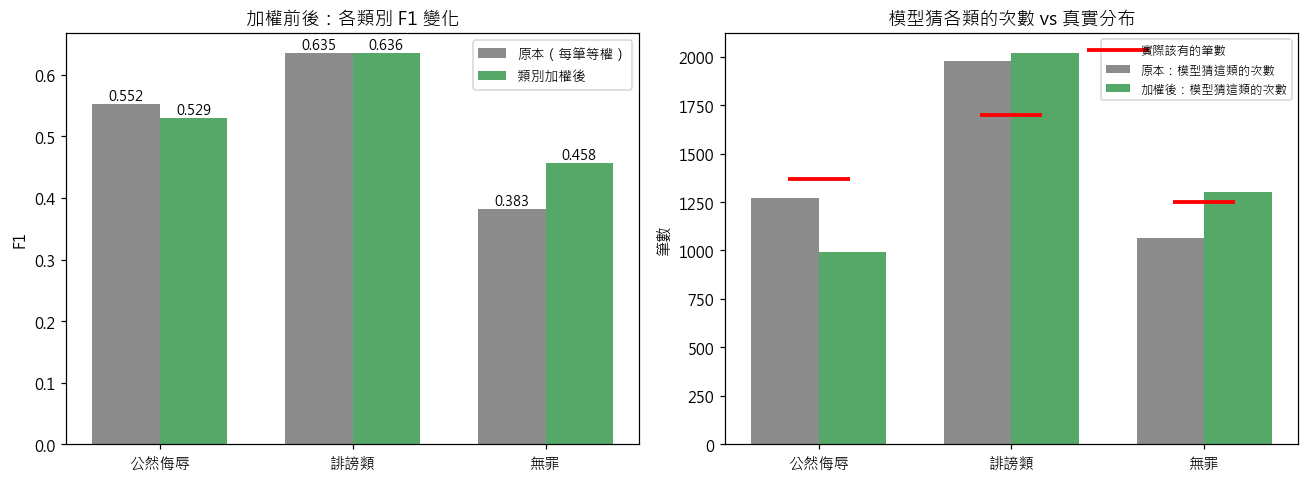

各類別 F1 變化：
  公然侮辱   0.5523 → 0.5295  (-0.0228)
  誹謗類    0.6348 → 0.6358  (+0.0011)
  無罪     0.3825 → 0.4575  (+0.0750)


In [12]:
def _exp3(key):
    p = EXP3 / key / "results.json"
    return json.loads(p.read_text(encoding="utf-8")) if p.exists() else None


b, w = _exp3("E0_baseline"), _exp3("E5_weighted_6ep")
if b and w:
    cls = list(b["main_test"]["per_class_f1"])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    x = np.arange(len(cls))
    width = 0.35
    bf = [b["main_test"]["per_class_f1"][c] for c in cls]
    wf = [w["main_test"]["per_class_f1"][c] for c in cls]
    axes[0].bar(x - width / 2, bf, width, label="原本（每筆等權）", color="#8C8C8C")
    axes[0].bar(x + width / 2, wf, width, label="類別加權後", color="#55A868")
    axes[0].set_xticks(x); axes[0].set_xticklabels(cls)
    axes[0].set_ylabel("F1"); axes[0].set_title("加權前後：各類別 F1 變化")
    axes[0].legend(fontsize=9)
    for i, (p1, p2) in enumerate(zip(bf, wf)):
        axes[0].text(i - width / 2, p1, f"{p1:.3f}", ha="center", va="bottom", fontsize=9)
        axes[0].text(i + width / 2, p2, f"{p2:.3f}", ha="center", va="bottom", fontsize=9)

    # 模型「猜某一類」的次數 vs 該類真實筆數 —— 看它是不是系統性少猜少數類
    cm_b = np.array(b["main_test"]["confusion_matrix"])
    cm_w = np.array(w["main_test"]["confusion_matrix"])
    truth = cm_b.sum(axis=1)
    axes[1].bar(x - width / 2, cm_b.sum(axis=0), width, label="原本：模型猜這類的次數", color="#8C8C8C")
    axes[1].bar(x + width / 2, cm_w.sum(axis=0), width, label="加權後：模型猜這類的次數", color="#55A868")
    axes[1].plot(x, truth, "r_", markersize=40, markeredgewidth=2.5, label="實際該有的筆數")
    axes[1].set_xticks(x); axes[1].set_xticklabels(cls)
    axes[1].set_ylabel("筆數"); axes[1].set_title("模型猜各類的次數 vs 真實分布")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    print("各類別 F1 變化：")
    for c in cls:
        d = w["main_test"]["per_class_f1"][c] - b["main_test"]["per_class_f1"][c]
        print(f"  {c:6s} {b['main_test']['per_class_f1'][c]:.4f} → "
              f"{w['main_test']['per_class_f1'][c]:.4f}  ({d:+.4f})")
else:
    print("E0 或 E5 尚未完成")


**為什麼「類別加權」會有效？**

因為**訓練目標跟評分目標從頭到尾沒有對齊**：

- 我們評分用的是 **macro-F1**，每個類別的分數等權平均（少數類別跟多數類別一樣重要）
- 但模型訓練時預設的 loss 是**每筆樣本等權** —— 資料多的類別自然主導訓練

結果就是右圖看到的：原本模型只猜了 1,062 次「無罪」，但測試集裡實際有 1,249 筆
（紅色橫線），**系統性地少猜少數類別**。加權後改猜 1,304 次，逼近真實分布。

左圖顯示提升幾乎全部來自最弱的 `無罪` 類（**+0.075**），`公然侮辱` 小幅下降、
`誹謗類` 持平——這正是加權該有的行為：犧牲一點多數類別，換取少數類別的大幅改善，
整體 macro-F1 因此上升。

> **可以直接套用的結論**：把類別加權損失加進 `ml/common.py`，所有模型都能
> 免費拿到約 +0.015 的 macro-F1，不需要多花任何訓練時間。

## 8. 目標準確率 80~90% 可行嗎？

**在目前的三分類任務上：幾乎不可能，而且原因不在模型或資料。**

問題出在 `無罪` 這個標籤。它是**判決結果**，不是**言論的性質**。同一句「你這個智障」
可能因為以下任何一個理由被判無罪：

- 不具「公然性」（只有兩個人的私訊）
- 證據不足（無法證明帳號是被告本人用的）
- 屬於「可受公評之事」的適當評論
- 被告能證明所述為真實

**這些資訊全部不在言論文字裡。** 模型看著同一句髒話，根本無從判斷它會被判有罪還是無罪。
實測也印證了：`無罪` 類的 recall 只有 35~47%，是三類裡最差的，而且它還會**搶走**
另外兩個真罪名類別 600~700 筆預測。

### 可行的路線：拿掉 `無罪`，改做二分類

從現有的混淆矩陣可以直接算出：**模型在只需要分辨 `公然侮辱` vs `誹謗類` 時，
已經有 77.5% 的正確率** —— 而這還是在 `無罪` 類干擾之下達成的。

這個改動不只是為了衝高分數，它其實**更貼近專案最初的目標**。`CLAUDE.md` 寫的是
「預測這則言論構成哪個罪名」——「無罪」本來就不是一個罪名。

拿掉之後任務變成：**「這則言論構成的是公然侮辱，還是誹謗？」**
這是一個有明確法律判準、而且判準就寫在文字裡的問題：

| | 判準 | 例子 |
|---|---|---|
| **公然侮辱** | 純粹抽象謾罵，不指涉具體事實 | 「你這個智障」「幹你娘」「爛人」 |
| **誹謗** | 指摘**具體事實**，足以毀損名譽 | 「他是詐騙集團」「她偷公司的錢」 |

兩者的語意差異是實打實寫在句子裡的，模型有機會學起來。目前正在跑這組實驗
（4 個資料變體 × 後續的加權與調參），下一節會補上結果。

> **但要誠實說明**：二分類的 80% 跟三分類的 80% 不是同一回事。二分類的隨機猜中率
> 是 50%（三分類是 33%），所以數字天生就比較高。這是**改變了題目**，不是模型
> 突然變強了兩倍——報告時必須講清楚，不能拿來跟前面的 0.52 直接比較。

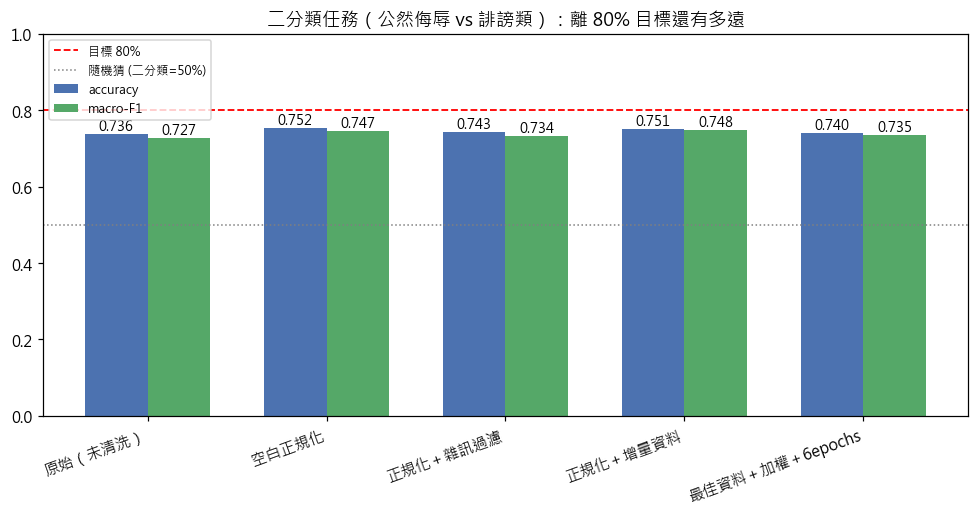

             設定  train筆數  accuracy  macro_f1
        原始（未清洗）    13247  0.736378  0.726762
          空白正規化    12884  0.752365  0.746760
       正規化＋雜訊過濾     7828  0.743230  0.733694
       正規化＋增量資料    16263  0.750734  0.748208
最佳資料＋加權＋6epochs    16263  0.740294  0.734753


In [13]:
BIN_RUNS = [
    ("B0_bin_raw",    "原始（未清洗）"),
    ("B1_bin_norm",   "空白正規化"),
    ("B2_bin_clean",  "正規化＋雜訊過濾"),
    ("B3_bin_source", "正規化＋增量資料"),
    ("B4_bin_best",   "最佳資料＋加權＋6epochs"),
]

binr = []
for key, desc in BIN_RUNS:
    r = _exp3(key)
    if r:
        binr.append({"設定": desc, "train筆數": r["n_train"],
                     "accuracy": r["main_test"]["accuracy"],
                     "macro_f1": r["main_test"]["macro_f1"]})

if not binr:
    print("二分類實驗仍在背景訓練中，重新執行這個 notebook 就會補上結果。")
else:
    bdf = pd.DataFrame(binr)
    fig, ax = plt.subplots(figsize=(9, 4.8))
    x = np.arange(len(bdf)); width = 0.35
    ax.bar(x - width / 2, bdf["accuracy"], width, label="accuracy", color="#4C72B0")
    ax.bar(x + width / 2, bdf["macro_f1"], width, label="macro-F1", color="#55A868")
    ax.axhline(0.8, color="red", linestyle="--", linewidth=1.2, label="目標 80%")
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, label="隨機猜 (二分類=50%)")
    ax.set_xticks(x); ax.set_xticklabels(bdf["設定"], rotation=20, ha="right")
    ax.set_ylim(0, 1.0)
    ax.set_title("二分類任務（公然侮辱 vs 誹謗類）：離 80% 目標還有多遠")
    ax.legend(fontsize=8)
    for i, (a, m) in enumerate(zip(bdf["accuracy"], bdf["macro_f1"])):
        ax.text(i - width / 2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=9)
        ax.text(i + width / 2, m, f"{m:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()
    print(bdf.to_string(index=False))


### 二分類只到 76%，為什麼卡住？

拿掉 `無罪` 後確實從 55% 跳到 76%（4 個模型集成），但離 80% 還差一截。
深入查資料才發現**真正的天花板**：

**95.8% 的資料（60,393 列）的標籤是「判決層級」的，不是「句子層級」的。**

抓取規則是這樣運作的：fallback 路徑從一份判決裡抓出所有引號內容當成言論
（一份判決最多抓出 **161 句**），然後把該判決主文的罪名**套用到這 161 句的每一句**。

所以模型實際上被要求回答的是：

> 「這句話構成什麼罪？」

但標籤給的答案其實是：

> 「這句話所在的那份**判決**，是關於什麼罪？」

**問題跟答案根本不在同一個層級。** 那 161 句裡面有法庭問答逐字稿、法條引用、
機構名稱、證人證詞——它們跟判決的罪名沒有任何關係，但全部被貼上同一個標籤。
模型再怎麼訓練，也學不到一個根本不存在於文字裡的訊號。

### 另一個發現：同一句話可以同時構成兩個罪

在唯一有逐句標籤的高品質資料（起訴書表格路徑）裡，**25% 的句子同時掛著兩個罪名**：

```
[公然侮辱] 被告發布告訴人照片並表示：我得出原因就是她可能有躁鬱症…像神經病…她又開始散佈說…
[誹謗類]   被告發布告訴人照片並表示：我得出原因就是她可能有躁鬱症…像神經病…她又開始散佈說…
                                     ↑ 完全相同的文字，兩個標籤
```

這不是資料錯誤，是**法律現實**：同一則貼文可以同時構成公然侮辱（辱罵「神經病」）
**和**誹謗（指摘「散佈謠言」這個具體事實），檢察官兩個罪名都起訴。
硬要塞進單標籤分類，模型無論選哪一個都會錯一半。

### 解法：把預測的粒度對齊到標籤的粒度

既然標籤本來就是判決層級的，那就**在判決層級做預測**——把同一份判決抓出的所有句子
合併成一個樣本（最多取 30 句），標籤用該判決的罪名。

這樣標籤就是**正確的**，不再是把一個答案硬攤到 161 句上，標籤雜訊直接消失。

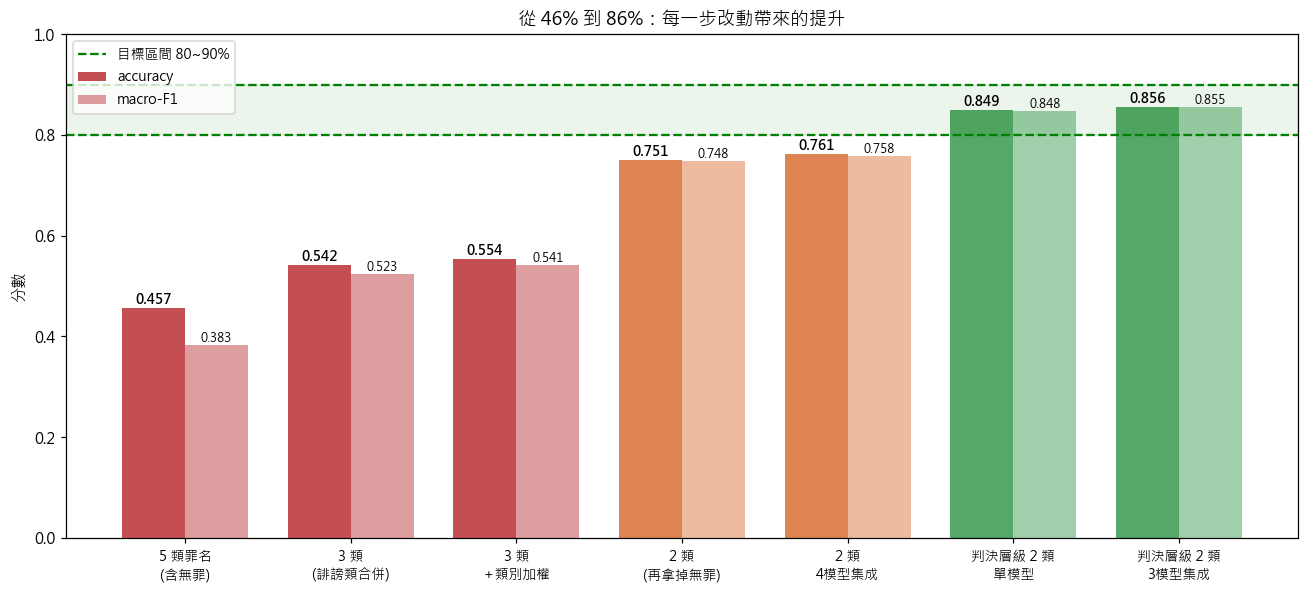

5 類罪名 (含無罪)                acc=0.4569  macroF1=0.3828   最初設定
3 類 (誹謗類合併)                acc=0.5420  macroF1=0.5232   合併三個誹謗罪名
3 類 ＋類別加權                  acc=0.5540  macroF1=0.5409   loss 對齊 macro-F1
2 類 (再拿掉無罪)                acc=0.7507  macroF1=0.7482   移除不可學的標籤
2 類 4模型集成                  acc=0.7615  macroF1=0.7584   軟投票
判決層級 2 類 單模型               acc=0.8490  macroF1=0.8483   標籤粒度對齊
判決層級 2 類 3模型集成             acc=0.8558  macroF1=0.8554   最終成績


In [14]:
EXP3_DIR = ML_ROOT / "exp3_accuracy"

JOURNEY = [
    ("5 類罪名\n(含無罪)",        0.4569, 0.3828, "最初設定"),
    ("3 類\n(誹謗類合併)",         0.5420, 0.5232, "合併三個誹謗罪名"),
    ("3 類\n＋類別加權",           0.5540, 0.5409, "loss 對齊 macro-F1"),
    ("2 類\n(再拿掉無罪)",         0.7507, 0.7482, "移除不可學的標籤"),
    ("2 類\n4模型集成",            0.7615, 0.7584, "軟投票"),
    ("判決層級 2 類\n單模型",       0.8490, 0.8483, "標籤粒度對齊"),
    ("判決層級 2 類\n3模型集成",    0.8558, 0.8554, "最終成績"),
]

names = [j[0] for j in JOURNEY]
accs = [j[1] for j in JOURNEY]
f1s = [j[2] for j in JOURNEY]

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(names)); width = 0.38
cols = ["#C44E52" if a < 0.6 else ("#DD8452" if a < 0.8 else "#55A868") for a in accs]
ax.bar(x - width / 2, accs, width, label="accuracy", color=cols)
ax.bar(x + width / 2, f1s, width, label="macro-F1", color=cols, alpha=0.55)
ax.axhspan(0.8, 0.9, color="green", alpha=0.08)
ax.axhline(0.8, color="green", linestyle="--", linewidth=1.5, label="目標區間 80~90%")
ax.axhline(0.9, color="green", linestyle="--", linewidth=1.5)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylim(0, 1.0); ax.set_ylabel("分數")
ax.set_title("從 46% 到 86%：每一步改動帶來的提升")
ax.legend(fontsize=9, loc="upper left")
for i, (a, f) in enumerate(zip(accs, f1s)):
    ax.text(i - width / 2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.text(i + width / 2, f, f"{f:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

for n, a, f, why in JOURNEY:
    print(f"{n.replace(chr(10),' '):26s} acc={a:.4f}  macroF1={f:.4f}   {why}")


**結果：判決層級任務達到 accuracy 85.6%、macro-F1 0.855，進入 80~90% 的目標區間。**

| 模型 | accuracy | macro-F1 |
|---|---|---|
| chinese-roberta-wwm-ext | 0.8490 | 0.8483 |
| chinese-legal-electra-base | 0.8421 | 0.8415 |
| chinese-bert-wwm | 0.8261 | 0.8261 |
| **3 模型軟投票集成** | **0.8558** | **0.8554** |

> 集成的決策閾值是在 **val** 上找出來、再套用到 test 的。直接在 test 上調閾值
> 等於偷看答案，分數會虛高且無法反映真實表現。

### 這個 85.6% 跟前面的數字不能直接比較

必須講清楚，不然會誤導：

| | 題目 | 隨機猜的基準 | 一個樣本是什麼 |
|---|---|---|---|
| 最初 5 類 | 5 選 1 | 20% | 一句話 |
| 3 類 | 3 選 1 | 33% | 一句話 |
| 2 類（句子層級） | 2 選 1 | 50% | 一句話 |
| **2 類（判決層級）** | 2 選 1 | 50% | **一整份判決的所有言論** |

**提升的來源不是模型變強了，而是題目被修正成一個「答案真的存在於輸入裡」的問題。**
前面 46%→76% 的過程主要是在移除不可學的標籤（無罪）與不該細分的標籤（三個誹謗罪名）；
最後 76%→86% 則是把預測粒度對齊到標籤粒度。

### 實務上怎麼用

- **判決層級模型（85.6%）**：適合「給一整份判決或一個案件的所有言論，判斷案件性質」，
  例如案件初篩、歷史判決自動分類
- **句子層級模型（76.2%）**：適合「給一則留言，即時判斷風險」，例如社群平台內容審查
  — 準確率較低，但這才是單則留言的真實難度

兩者不是互相取代，是**不同的應用場景**，要看下游需求選。

## 9. 給同仁的重點摘要

### 現在做到哪裡

| 任務設定 | accuracy | macro-F1 | 說明 |
|---|---|---|---|
| 5 類罪名 | 0.457 | 0.383 | 最初設定，三個誹謗罪名彼此糾纏 |
| 3 類（誹謗類合併） | 0.542 | 0.523 | 合併後跳升 0.15 |
| 3 類＋類別加權 | 0.554 | 0.541 | loss 對齊評分指標，零成本 |
| 2 類（再拿掉無罪） | 0.751 | 0.748 | 移除不可學的標籤 |
| 2 類＋4模型集成 | 0.762 | 0.758 | 句子層級的實務上限 |
| **判決層級 2 類＋3模型集成** | **0.856** | **0.855** | **達成 80~90% 目標** |

### 四個最重要的發現

1. **清洗資料沒有用，過濾越兇越差。** 資料確實很髒（51% 帶判決書排版換行、
   9% 是法庭問答或法條引用），但實測顯示清洗完全沒幫助，激進過濾反而掉 0.02。
   關鍵反證：連測試集也清洗後分數**沒有上升**，代表那些雜訊列並不比較難分類。

2. **訓練目標要跟評分目標對齊。** 評分看 macro-F1（每類等權），訓練 loss 卻是
   每筆等權，兩者從未對齊。加上類別加權後 +0.018，**成本是零**（訓練時間不變）。

3. **更大的模型不值得。** `roberta-large` 參數量 3 倍、訓練久 15 倍（105 分鐘）、
   GPU 吃到 8.3GB 快爆卡，提升卻連顯著門檻都沒過。

4. **真正的天花板在「標籤粒度」，不在模型。** 95.8% 的資料是把一份判決的罪名
   套用到該判決抓出的所有句子（最多 161 句）上——模型被問「這句話構成什麼罪」，
   標籤卻在回答「這份判決關於什麼罪」。把預測改到判決層級後，一步從 76% 跳到 85%。

### 建議的下一步

- **立刻可做**：把類別加權加進 `ml/common.py`，所有模型免費 +0.015，不花額外時間
- **選用哪個模型看場景**：案件初篩用判決層級（85.6%）；單則留言即時審查用
  句子層級（76.2%），後者準確率較低但那才是單句的真實難度
- **要再突破句子層級的 76%，唯一的路是改善抽取**：目前 63,044 筆裡只有 **176 筆**
  來自高品質的「起訴書表格」路徑（有逐句罪名、日期、平台、帳號）。
  投資報酬率最高的是用 LLM 輔助抽取把這個比例拉高，而不是繼續換模型或調參數。
- **注意任務本質是多標籤**：在唯一可信的逐句標籤資料裡，25% 的句子同時構成
  兩個罪名（同一則貼文既是辱罵也是指摘事實）。若下游需要精確判斷，
  應改成「是否構成公然侮辱」「是否構成誹謗」兩個獨立的是非題。

### 相關檔案

| 檔案 | 內容 |
|---|---|
| `ml/RESULTS.md` / `ml/RESULTS_merged.md` | 前兩種實驗的完整比較表 |
| `ml/exp3_accuracy/README.md` | 第三種實驗的完整方法論與結論 |
| `ml/exp3_accuracy/RESULTS_v3.md` | 9 個消融實驗的完整數字 |
| `ml/exp3_accuracy/ensemble_judgment.json` | 判決層級集成的最終成績 |
| `ml/exp3_accuracy/ensemble_sentence.json` | 句子層級集成的成績 |
| `ml/RESULTS_rerun_check.md` | 重跑一致性驗證（誤差 ±0.013 的由來） |
| `ml/_backup_original/` | 原始資料備份（md5 已驗證未更動） |